In [1]:
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    trasformation_X_to_E,
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    P_E_CMND
    )

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


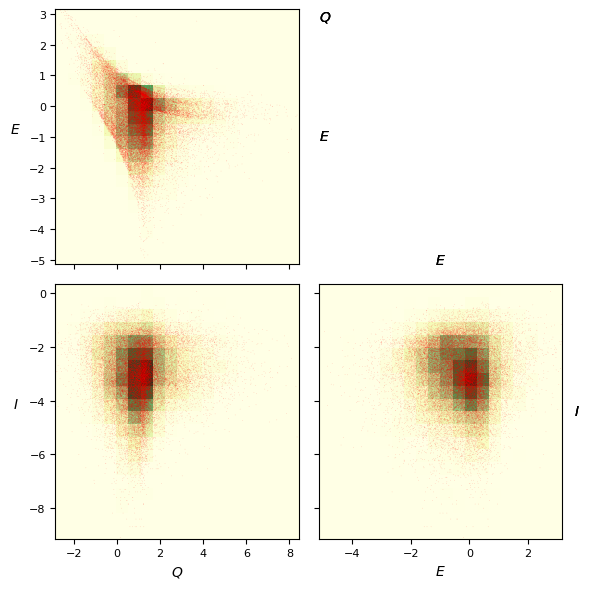

In [3]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [4]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        #print("evaluating at: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        #print("orbital elements: ", q, e, i, Omega, w, M, a)
        if q > 1.35 or e >= 1:
            #print(" ----------------- Not sense orbit -----------------")
            P.flat[idx] = 0
        else:
            with np.errstate(divide='ignore', invalid='ignore'):
                J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
                J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
                det = np.linalg.det(J)
                det_QEI = np.linalg.det(J_qei_to_QEI)
                if det == 0 or not np.isfinite(det):
                    #print(" ----------------- Cero determinant -----------------")
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
                    #if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                    #    print("Nan value encounter: ", P_E_CMND(q, e, i, F), abs(inv_det), abs(det_QEI))
                    #print(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_AEI)) 
    
    return P.reshape(shape)

In [5]:
def box_surface_integral_P_X_CMND(center, widths, velocities, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the integral of P_X_CMND over a position box (x, y, z) with fixed velocities.
    Integrates only over positions in a box centered at (cx, cy, cz) with widths (dx, dy, dz),
    while keeping velocities constant (vx = cte, vy = cte, vz = cte).

    Parameters:
        center: tuple/list/array of (cx, cy, cz) position center
        widths: tuple/list/array of (dx, dy, dz) position side lengths
        velocities: tuple/list/array of (vx, vy, vz) constant velocities
        max_elements: tuple/list/array of (q_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension
        mu: gravitational parameter
        F: FitCMND object

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    cx, cy, cz = center
    dx, dy, dz = widths
    vx, vy, vz = velocities
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for position dimensions only
    x_pts = cx + 0.5*dx*pts
    y_pts = cy + 0.5*dy*pts
    z_pts = cz + 0.5*dz*pts

    # Create meshgrid only for position quadrature points
    X, Y, Z = np.meshgrid(x_pts, y_pts, z_pts, indexing='ij')
    WX, WY, WZ = np.meshgrid(wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    WF = (WX * WY * WZ).ravel()
    
    # Create constant velocity arrays (same size as position arrays)
    VXf = np.full_like(Xf, vx)
    VYf = np.full_like(Yf, vy)
    VZf = np.full_like(Zf, vz)
    
    # Evaluate P at all points with constant velocities
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor (only position dimensions)
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz)
    return integral

In [9]:
x_min, x_max = -2, 2
y_min, y_max = -2, 2

z_center = 0.0

dx_cell, dy_cell, dz_cell = 0.1, 0.1, 0.1
widths = np.array([dx_cell, dy_cell, dz_cell])

vx = 0.0
vy = (mu/1.52)**0.5
vz = 0.0
center_vel = np.array([vx, vy, vz])

max_elements = (1.35, 1.0, np.pi) 

x_vals = np.arange(x_min, x_max + dx_cell, dx_cell)
y_vals = np.arange(y_min, y_max + dy_cell, dy_cell)

degree = 6

dtype = [
    ("value", float),
    ("x", float),
    ("y", float)
]

probability_map = np.zeros((len(y_vals), len(x_vals)), dtype=dtype)

print("Starting probability mapping...")
for i, y_c in enumerate(tqdm(y_vals, desc="Y-axis progress")):
    for j, x_c in enumerate(x_vals):         

        center = np.array([x_c, y_c, z_center])

        try:
        # Calculate the integral for this hypervolume
            prob_value = box_surface_integral_P_X_CMND(
                center, widths, 
                center_vel, 
                max_elements, 
                degree, 
                mu=mu, 
                F=F
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = (prob_value, x_c, y_c)
        print(x_c, y_c, prob_value, i, j)
     
# Save to a .dat file
print("Mapping complete!")
np.save(f"data_results/method 6/PX_fixedv_xmin={x_min}_xmax={x_max}_ymin={y_min}_ymax={y_max}_vx={vx}_vy={np.round(vy, 2)}_vz={vz}.npy", probability_map)

Starting probability mapping...


Y-axis progress:   0%|          | 0/41 [00:00<?, ?it/s]

-2.0 -2.0 1.8807639848963594e-32 0 0
-1.9 -2.0 9.842031517723292e-31 0 1
-1.7999999999999998 -2.0 1.2301209350397081e-29 0 2
-1.6999999999999997 -2.0 5.812762507742809e-29 0 3
-1.5999999999999996 -2.0 1.3527689116501314e-28 0 4
-1.4999999999999996 -2.0 3.5716277032325815e-28 0 5
-1.3999999999999995 -2.0 8.769663596149373e-28 0 6
-1.2999999999999994 -2.0 2.0610072080650767e-27 0 7
-1.1999999999999993 -2.0 4.938302084860438e-27 0 8
-1.0999999999999992 -2.0 1.137800927050736e-26 0 9
-0.9999999999999991 -2.0 2.4343474604753685e-26 0 10
-0.899999999999999 -2.0 4.714541379532942e-26 0 11
-0.7999999999999989 -2.0 7.962601444447033e-26 0 12
-0.6999999999999988 -2.0 1.1061401041203312e-25 0 13
-0.5999999999999988 -2.0 1.1513738875289923e-25 0 14
-0.49999999999999867 -2.0 7.706832855650175e-26 0 15
-0.3999999999999986 -2.0 2.556972793308751e-26 0 16
-0.2999999999999985 -2.0 2.688805948900696e-27 0 17
-0.1999999999999984 -2.0 2.3898924437317517e-27 0 18
-0.09999999999999831 -2.0 3.693606840548509

Y-axis progress:   2%|▏         | 1/41 [00:11<07:29, 11.24s/it]

1.9000000000000035 -2.0 1.7204674027086938e-13 0 39
2.0000000000000036 -2.0 2.010205869413659e-16 0 40
-2.0 -1.9 1.8408783323076327e-32 1 0
-1.9 -1.9 2.191155611144759e-30 1 1
-1.7999999999999998 -1.9 6.14705168819413e-29 1 2
-1.6999999999999997 -1.9 5.796646227502077e-28 1 3
-1.5999999999999996 -1.9 4.5680706485797546e-27 1 4
-1.4999999999999996 -1.9 1.2269710967459523e-26 1 5
-1.3999999999999995 -1.9 1.2007402986230336e-26 1 6
-1.2999999999999994 -1.9 7.656150861063952e-27 1 7
-1.1999999999999993 -1.9 9.502485627646742e-27 1 8
-1.0999999999999992 -1.9 2.0587840060660687e-26 1 9
-0.9999999999999991 -1.9 4.5206005634939986e-26 1 10
-0.899999999999999 -1.9 9.104823356864733e-26 1 11
-0.7999999999999989 -1.9 1.6155362415327585e-25 1 12
-0.6999999999999988 -1.9 2.384308933524161e-25 1 13
-0.5999999999999988 -1.9 2.671557118473409e-25 1 14
-0.49999999999999867 -1.9 1.9559299735601199e-25 1 15
-0.3999999999999986 -1.9 7.239553856588363e-26 1 16
-0.2999999999999985 -1.9 8.596917218423547e-27

...

1.9000000000000035 1.8000000000000034 1.2359027799377284e-13 38 39
2.0000000000000036 1.8000000000000034 7.855750801832878e-15 38 40
-2.0 1.9000000000000035 1.8408783323205342e-32 39 0
-1.9 1.9000000000000035 2.1911556111448583e-30 39 1
-1.7999999999999998 1.9000000000000035 6.147051688202156e-29 39 2
-1.6999999999999997 1.9000000000000035 5.7966462275034665e-28 39 3
-1.5999999999999996 1.9000000000000035 4.5680706485758444e-27 39 4
-1.4999999999999996 1.9000000000000035 1.2269710967462581e-26 39 5
-1.3999999999999995 1.9000000000000035 1.2007402986230046e-26 39 6
-1.2999999999999994 1.9000000000000035 7.656150861068588e-27 39 7
-1.1999999999999993 1.9000000000000035 9.502485627645207e-27 39 8
-1.0999999999999992 1.9000000000000035 2.0587840060649776e-26 39 9
-0.9999999999999991 1.9000000000000035 4.520600563492659e-26 39 10
-0.899999999999999 1.9000000000000035 9.104823356865281e-26 39 11
-0.7999999999999989 1.9000000000000035 1.6155362415325812e-25 39 12
-0.6999999999999988 1.9000000

Y-axis progress:  98%|█████████▊| 40/41 [07:14<00:14, 14.89s/it]

1.9000000000000035 1.9000000000000035 1.9151293879849664e-13 39 39
2.0000000000000036 1.9000000000000035 2.013154978735611e-15 39 40
-2.0 2.0000000000000036 1.8807639849280941e-32 40 0
-1.9 2.0000000000000036 9.842031517785408e-31 40 1
-1.7999999999999998 2.0000000000000036 1.2301209350452719e-29 40 2
-1.6999999999999997 2.0000000000000036 5.812762507754978e-29 40 3
-1.5999999999999996 2.0000000000000036 1.3527689116503482e-28 40 4
-1.4999999999999996 2.0000000000000036 3.571627703231747e-28 40 5
-1.3999999999999995 2.0000000000000036 8.769663596155622e-28 40 6
-1.2999999999999994 2.0000000000000036 2.0610072080655054e-27 40 7
-1.1999999999999993 2.0000000000000036 4.938302084862842e-27 40 8
-1.0999999999999992 2.0000000000000036 1.1378009270502528e-26 40 9
-0.9999999999999991 2.0000000000000036 2.434347460474159e-26 40 10
-0.899999999999999 2.0000000000000036 4.7145413795340176e-26 40 11
-0.7999999999999989 2.0000000000000036 7.962601444445199e-26 40 12
-0.6999999999999988 2.000000000

Y-axis progress: 100%|██████████| 41/41 [07:30<00:00, 10.98s/it]

1.9000000000000035 2.0000000000000036 1.7204674026964232e-13 40 39
2.0000000000000036 2.0000000000000036 2.0102058694464718e-16 40 40
Mapping complete!


<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_11480\3183872312.py:22: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


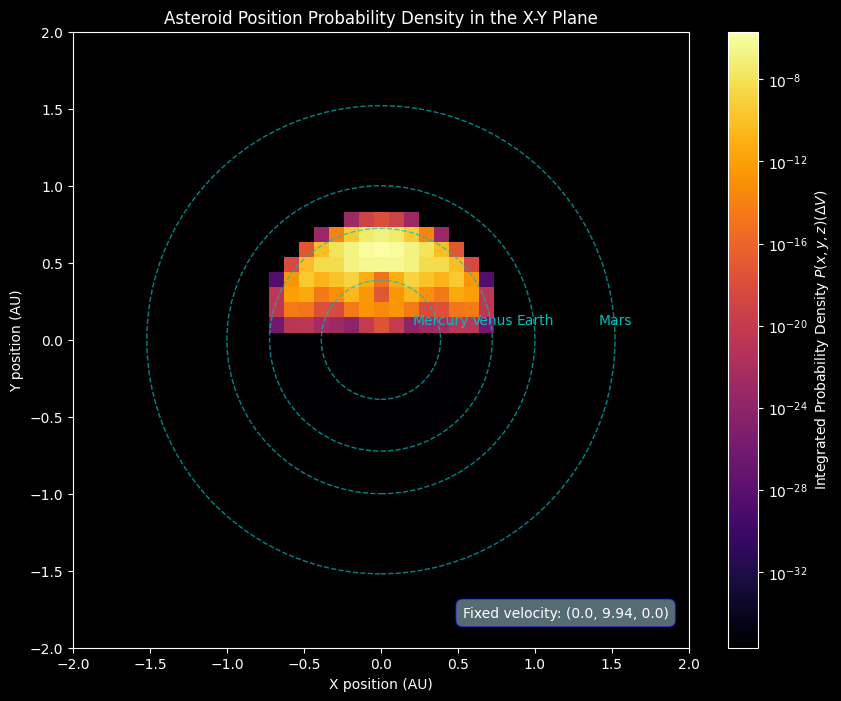

In [80]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=9.94_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = 9.94

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'].T, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest', 
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=9.94_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

In [91]:
integral_grid[15]

array([(0.00000000e+00, -2.00000000e+00, -0.5),
       (0.00000000e+00, -1.90000000e+00, -0.5),
       (0.00000000e+00, -1.80000000e+00, -0.5),
       (0.00000000e+00, -1.70000000e+00, -0.5),
       (0.00000000e+00, -1.60000000e+00, -0.5),
       (0.00000000e+00, -1.50000000e+00, -0.5),
       (0.00000000e+00, -1.40000000e+00, -0.5),
       (0.00000000e+00, -1.30000000e+00, -0.5),
       (0.00000000e+00, -1.20000000e+00, -0.5),
       (0.00000000e+00, -1.10000000e+00, -0.5),
       (0.00000000e+00, -1.00000000e+00, -0.5),
       (0.00000000e+00, -9.00000000e-01, -0.5),
       (0.00000000e+00, -8.00000000e-01, -0.5),
       (1.08189240e-34, -7.00000000e-01, -0.5),
       (1.16729022e-24, -6.00000000e-01, -0.5),
       (1.03480925e-22, -5.00000000e-01, -0.5),
       (1.56209280e-21, -4.00000000e-01, -0.5),
       (8.54159573e-21, -3.00000000e-01, -0.5),
       (1.03709425e-20, -2.00000000e-01, -0.5),
       (7.13735058e-22, -1.00000000e-01, -0.5),
       (1.42266355e-16,  1.77635684e-15,

In [92]:
integral_grid[25]

array([(0.00000000e+00, -2.00000000e+00, 0.5),
       (0.00000000e+00, -1.90000000e+00, 0.5),
       (0.00000000e+00, -1.80000000e+00, 0.5),
       (0.00000000e+00, -1.70000000e+00, 0.5),
       (0.00000000e+00, -1.60000000e+00, 0.5),
       (0.00000000e+00, -1.50000000e+00, 0.5),
       (0.00000000e+00, -1.40000000e+00, 0.5),
       (0.00000000e+00, -1.30000000e+00, 0.5),
       (0.00000000e+00, -1.20000000e+00, 0.5),
       (0.00000000e+00, -1.10000000e+00, 0.5),
       (0.00000000e+00, -1.00000000e+00, 0.5),
       (0.00000000e+00, -9.00000000e-01, 0.5),
       (0.00000000e+00, -8.00000000e-01, 0.5),
       (1.08189201e-34, -7.00000000e-01, 0.5),
       (1.16729022e-24, -6.00000000e-01, 0.5),
       (1.03480925e-22, -5.00000000e-01, 0.5),
       (1.56209280e-21, -4.00000000e-01, 0.5),
       (8.54159573e-21, -3.00000000e-01, 0.5),
       (1.03709425e-20, -2.00000000e-01, 0.5),
       (7.13735058e-22, -1.00000000e-01, 0.5),
       (1.42266355e-16,  1.77635684e-15, 0.5),
       (2.212

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_11480\1775542039.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


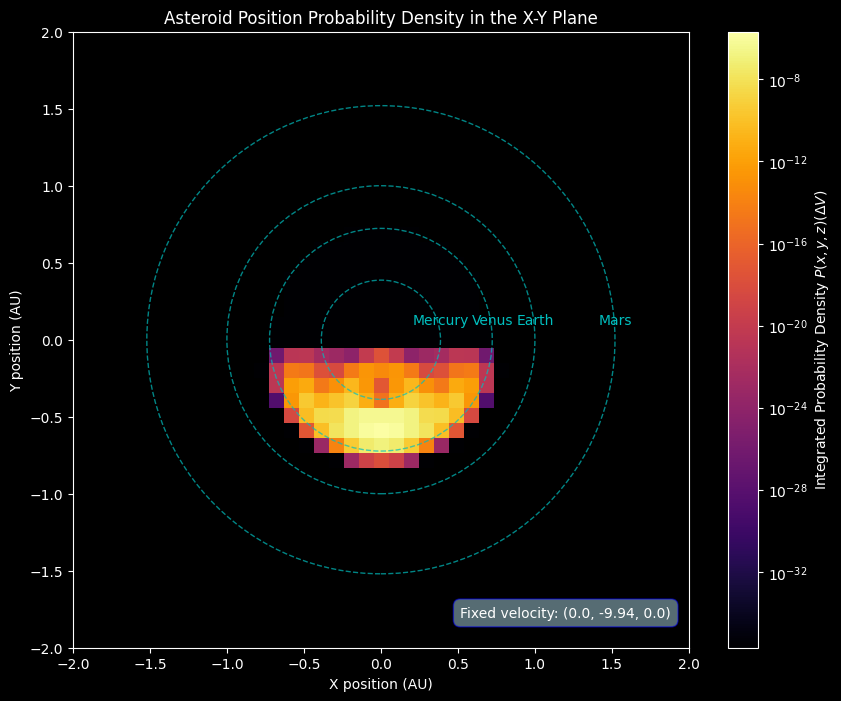

In [79]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-9.94_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = -9.94

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'].T,
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-9.94_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\2075011767.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


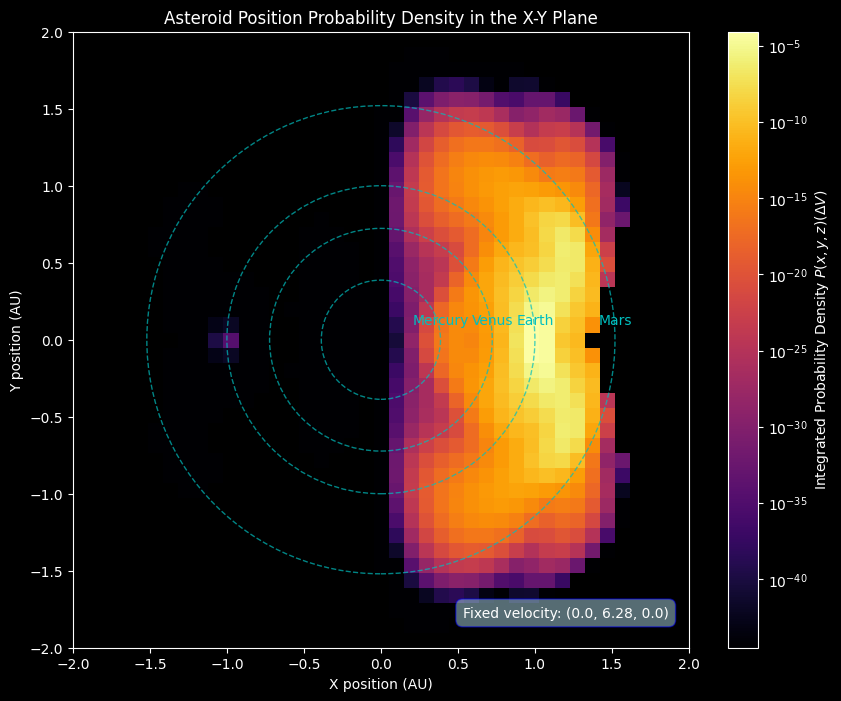

In [12]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = 6.28

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box')
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\3316823704.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


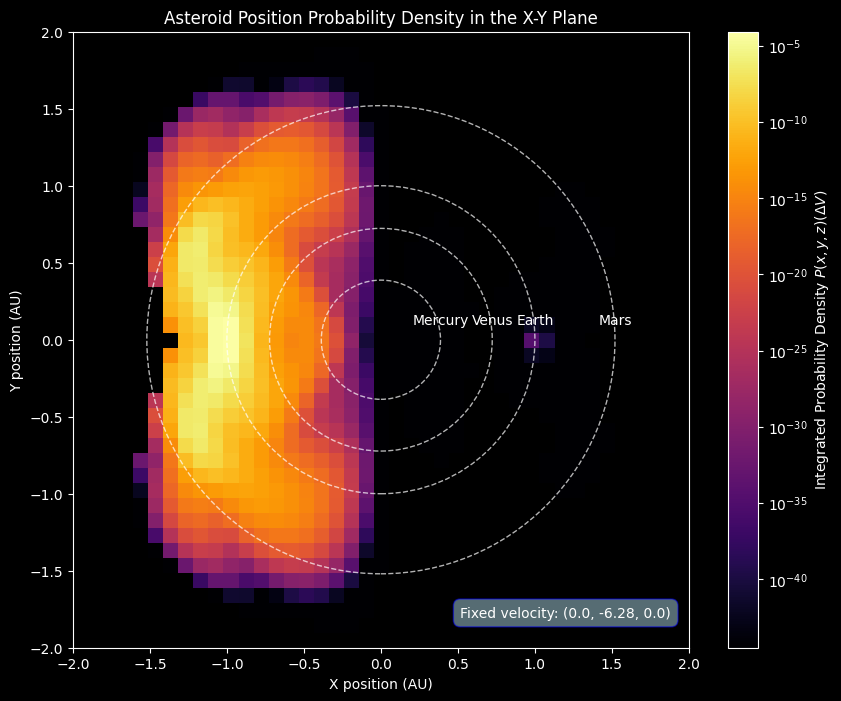

In [11]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-6.28_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = -6.28

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='white', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='white', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-6.28_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\3118552977.py:20: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


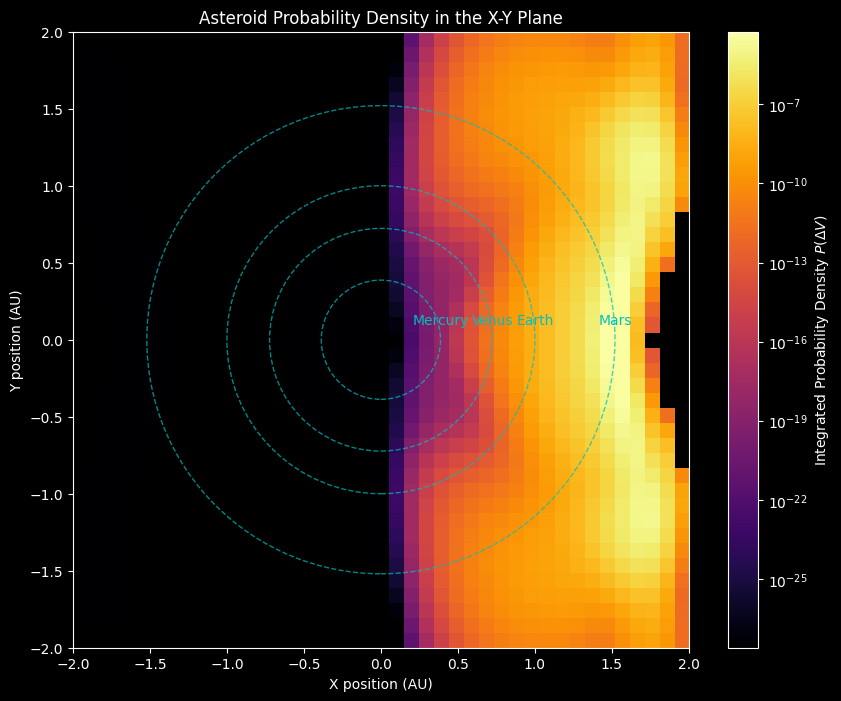

In [10]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=4.44_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\289382936.py:20: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


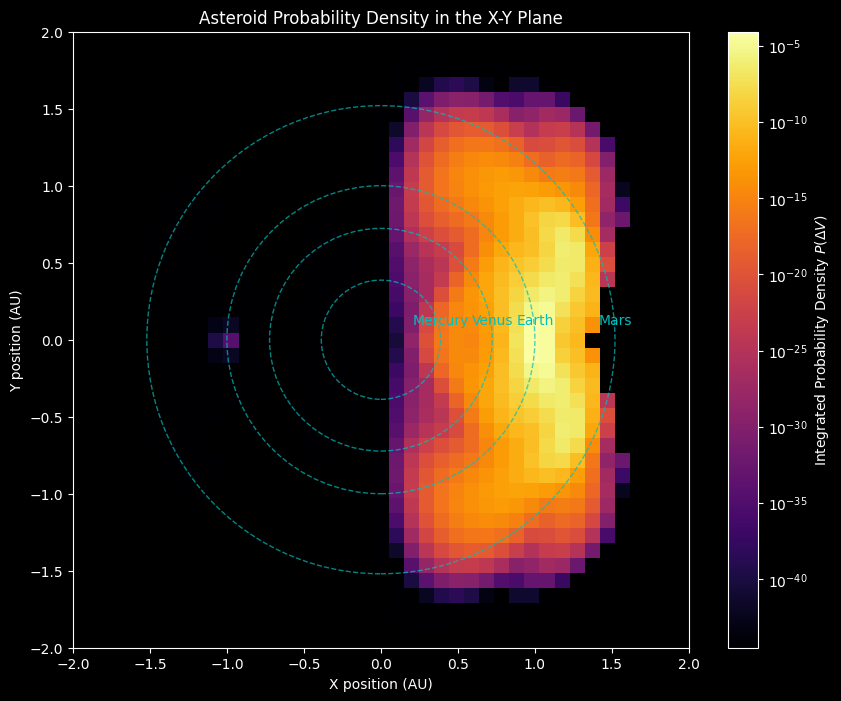

In [9]:

with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0_2.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()